<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_1_SLR/17_1_3_SLR_LINE_Assumptions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Linear Regression: The LINE Assumptions (Diagnosing the Model)

Author: Brad Sheese

---

## What This Notebook Is About

In Notebooks 17_1_1 and 17_1_2 the Palmer Penguins data cooperated beautifully. We fit a line, it fit well, the p-values were tiny, the confidence interval was tight, and we declared victory.

But here's the uncomfortable truth about simple linear regression:

> **OLS will draw a line through anything. It doesn't care whether a line is a good idea.**

Hand it a perfect straight-line relationship — you get a great fit. Hand it a parabola, a cloud of pure noise, a sine wave, or 300 data points with one huge outlier — you still get a slope, an $R^2$, a p-value, and a confidence interval. The library never complains. It just fits a line and reports statistics, even when those statistics are dangerously misleading.

The whole inferential machinery from Notebook 17_1_2 — the `std err`, the t-statistic, the p-value, the CI — is built on a set of assumptions about how the data behave. When those assumptions hold, the numbers in the summary table are trustworthy. When they don't, the numbers can be completely wrong *while still looking beautiful on the page*.

Statisticians summarize these assumptions with a handy mnemonic: **LINE**.

| Letter | Assumption | Plain English |
|:-:|---|---|
| **L** | **Linearity** | The true relationship between $x$ and $y$ is actually a line. |
| **I** | **Independence** | Each observation's error is independent of every other observation's. |
| **N** | **Normality of residuals** | Residuals are bell-curve distributed. |
| **E** | **Equal variance** (homoscedasticity) | The spread of residuals is constant across all values of $x$. |

This notebook is about how to check each one. We're going to ditch the well-behaved penguins and pick up a dataset that violates multiple assumptions at once — **Auto MPG** — so we can actually see what failure looks like.

## Setup

The **Auto MPG** dataset has 392 cars from the 1970s and 1980s. We'll predict a car's fuel efficiency (**`mpg`**, miles per gallon) from its engine **`displacement`** (cubic inches — basically a measure of engine size).

The expected story: bigger engines burn more gas, so higher displacement should mean lower mpg.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from scipy import stats

sns.set_style('whitegrid')
rng = np.random.default_rng(seed=42)

mpg = sns.load_dataset('mpg').dropna().reset_index(drop=True)
print(f'Cars: {len(mpg)}')
mpg[['mpg', 'displacement', 'horsepower', 'weight']].head()

Cars: 392


,mpg,displacement,horsepower,weight
0,18.0,307.0,130.0,3504
1,15.0,350.0,165.0,3693
2,18.0,318.0,150.0,3436
3,16.0,304.0,150.0,3433
4,17.0,302.0,140.0,3449


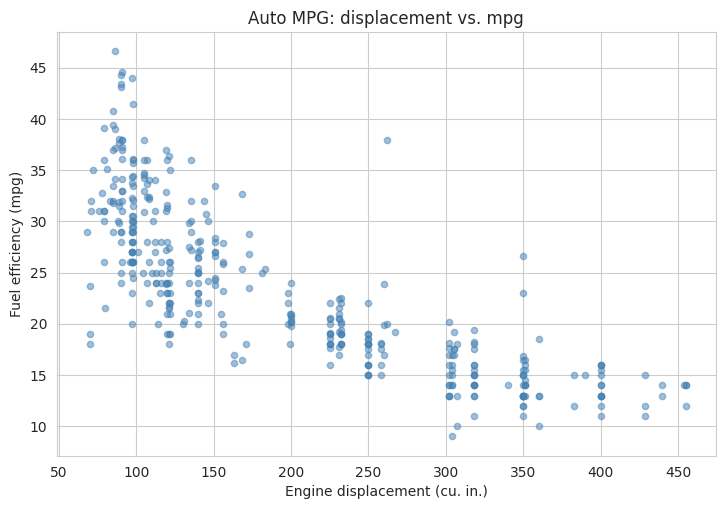

In [2]:
# Rule from Notebook 17_0_2: always look at the data.
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.scatter(mpg['displacement'], mpg['mpg'], s=20, alpha=0.5, color='steelblue')
ax.set_xlabel('Engine displacement (cu. in.)')
ax.set_ylabel('Fuel efficiency (mpg)')
ax.set_title('Auto MPG: displacement vs. mpg')
plt.show()

Even before we fit anything, your eyes should be picking up a few things:

1. Yes, bigger engines mean lower mpg — a clear negative trend.
2. But the trend is **not straight**. The cloud curves. As displacement grows past roughly 200 cu. in., mpg stops falling as fast. The relationship is closer to a hyperbola than a line.
3. The **spread** looks different at different displacements too — the small-engine cars (left side) show mpgs ranging from ~20 to 45, while the big-engine cars (right side) are clustered tightly between 10 and 15.

Keep those two observations in mind. We're going to watch OLS ignore both of them, and then watch the diagnostics catch it.

### Fit the line and get the summary that will lie to us

In [3]:
X_sm = sm.add_constant(mpg['displacement'])
y = mpg['mpg']

model = sm.OLS(y, X_sm).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.648
Model:                            OLS   Adj. R-squared:                  0.647
Method:                 Least Squares   F-statistic:                     718.7
Date:                Tue, 05 May 2026   Prob (F-statistic):           1.66e-90
Time:                        15:50:58   Log-Likelihood:                -1156.4
No. Observations:                 392   AIC:                             2317.
Df Residuals:                     390   BIC:                             2325.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           35.1206      0.494     71.033   

Read that summary the way a junior analyst would:

- $R^2 = 0.648$. Not bad — displacement explains almost 65% of the variation in mpg.
- Slope: $-0.060$ mpg per cu. in. Adding 100 cu. in. of engine costs you about 6 mpg. Sensible.
- $p < 0.001$ on the slope. Wildly significant.
- CI: $[-0.064, -0.056]$. Very tight.

If you stopped here and wrote up your results, you would report all of those numbers. And all of them — every single one — is built on assumptions we haven't checked. Let's draw the fitted line on top of the data and see what we've actually told the computer to fit.

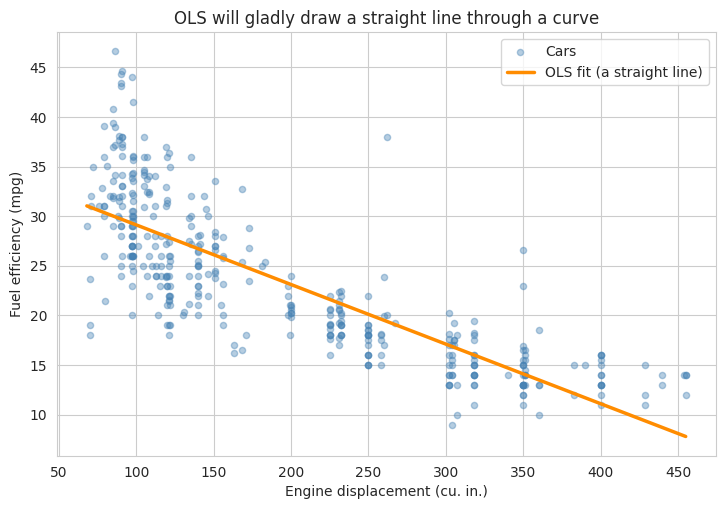

In [4]:
x_grid = np.linspace(mpg['displacement'].min(), mpg['displacement'].max(), 200)
y_pred = model.params['const'] + model.params['displacement'] * x_grid

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.scatter(mpg['displacement'], mpg['mpg'], s=20, alpha=0.4, color='steelblue', label='Cars')
ax.plot(x_grid, y_pred, color='darkorange', linewidth=2.5, label='OLS fit (a straight line)')
ax.set_xlabel('Engine displacement (cu. in.)')
ax.set_ylabel('Fuel efficiency (mpg)')
ax.set_title('OLS will gladly draw a straight line through a curve')
ax.legend()
plt.show()

The line **under-predicts mpg at the two extremes** (where the points sit above the line) and **over-predicts it in the middle** (where points sit below). That is the classic signature of a line being asked to approximate a curve. The model is systematically wrong in a pattern, not just randomly off.

And yet the summary table told us it was all fine. That gap — between *what the statistics claim* and *what the picture obviously shows* — is what the LINE diagnostics are designed to expose.

---

## Section 1 — L: Linearity

> **The assumption:** the true relationship between $x$ and $y$ is actually a straight line.

The way we diagnose every single LINE assumption is the same: we compute the residuals and go hunting for patterns. If the model's assumptions hold, the residuals should look like random noise with no structure. If a pattern shows up, the assumption is broken.

For linearity, the standard diagnostic is the **residual plot**: residual $e_i = y_i - \hat{y}_i$ on the y-axis, versus $x$ (or the fitted value $\hat{y}$) on the x-axis. Then we overlay a smooth curve (a "lowess" smoother) to make any pattern obvious. Seaborn's `residplot` does this in one line.

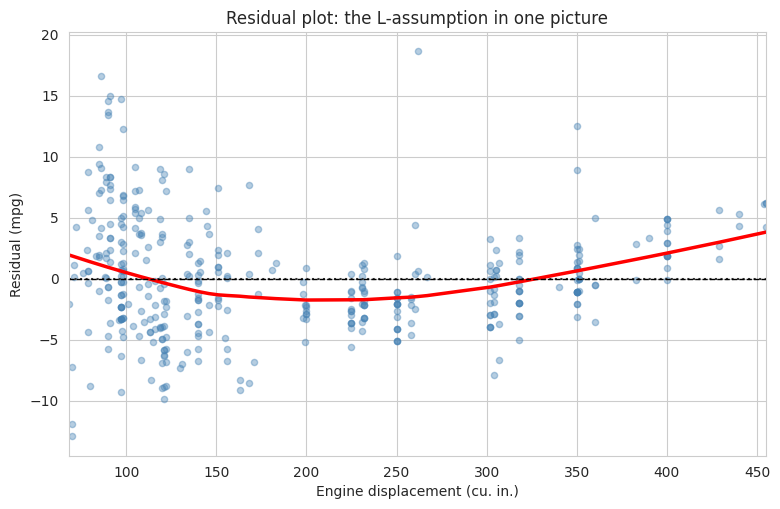

In [5]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.residplot(
    x=mpg['displacement'], y=mpg['mpg'],
    lowess=True,
    scatter_kws={'s': 20, 'alpha': 0.4, 'color': 'steelblue'},
    line_kws={'color': 'red', 'lw': 2.5},
    ax=ax,
)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Engine displacement (cu. in.)')
ax.set_ylabel('Residual (mpg)')
ax.set_title('Residual plot: the L-assumption in one picture')
plt.show()

**There's the smoking gun.** The red lowess curve carves out a distinct **U-shape**: residuals are positive on the left, dive negative in the middle, and climb back positive on the right. That's exactly what you'd expect if you forced a straight line through a curve.

> **The rule:** in a residual plot, you want a *horizontal band of noise* — random scatter around zero with no trend, no curve, no pattern. Anything else means the model has missed something systematic.

A U-shape (or any other shape) in the residuals is the residual plot screaming *"the relationship isn't linear"*. We'll learn how to fix this in Notebook 17_1_5 — most commonly by transforming $x$ or $y$ (for example, fitting `mpg` to `1/displacement` or to `log(displacement)` will straighten this curve dramatically).

---

## Section 2 — I: Independence

> **The assumption:** each observation's residual is independent of every other observation's residual.

This is the slipperiest of the four assumptions, because independence is hard to see by eye. The classic way it fails is in **time-series data**: if you predict today's stock price and get it a bit too high, you'll probably also get tomorrow's a bit too high, because consecutive days' errors are correlated. Or imagine predicting the height of students but grouping them by classroom — kids in the same classroom might share nutrition, exercise habits, genes, and so on, making their residuals correlated within classrooms.

Our car dataset isn't a time series, and each car is basically its own independent observation, so this assumption should hold fine. But here's how you'd check it if you were worried.

### The Durbin–Watson statistic

Scroll up to the statsmodels summary and look at the line `Durbin-Watson: 0.926`. This is a quick-and-dirty test for *serial correlation* in residuals: do neighboring residuals (when ordered the way the data arrived) look alike?

The rule of thumb:

- **DW $\approx 2.0$** — residuals look independent. Good.
- **DW $< 1.5$** — consecutive residuals are positively correlated (consecutive errors drift together). Warning sign.
- **DW $> 2.5$** — consecutive residuals are negatively correlated (they bounce). Also a warning sign.

Our DW is 0.926, which looks alarming on paper — but it almost certainly reflects the fact that the dataset is sorted by model year, so cars from similar eras sit next to each other in the dataframe. That's an artifact of row ordering, not a real independence problem between cars. The correct response is *don't worry about DW unless your data has a natural order* (time, space, or group membership).

For cross-sectional data like one-row-per-penguin or one-row-per-car, independence is usually a safe assumption, and you won't spend much time on it. We'll encounter it again properly in any notebook that involves time series.

---

## Section 3 — N: Normality of Residuals

> **The assumption:** the residuals are drawn from a normal distribution — a bell curve centered on zero.

Why does the math want residuals to be bell-shaped? Because the classical formulas for the standard error, the t-statistic, the p-value, and the confidence interval all come from probability theory that assumes normal errors. If the residuals are wildly non-normal, those formulas can be off.

Good news: with a reasonably large sample (say, 30+), the **Central Limit Theorem** kicks in and makes the inference fairly robust to modest non-normality. So this assumption is rarely a deal-breaker in large datasets. But we should still check it.

We'll use two diagnostics: a **histogram of residuals** (quick visual) and a **Q–Q plot** (more precise).

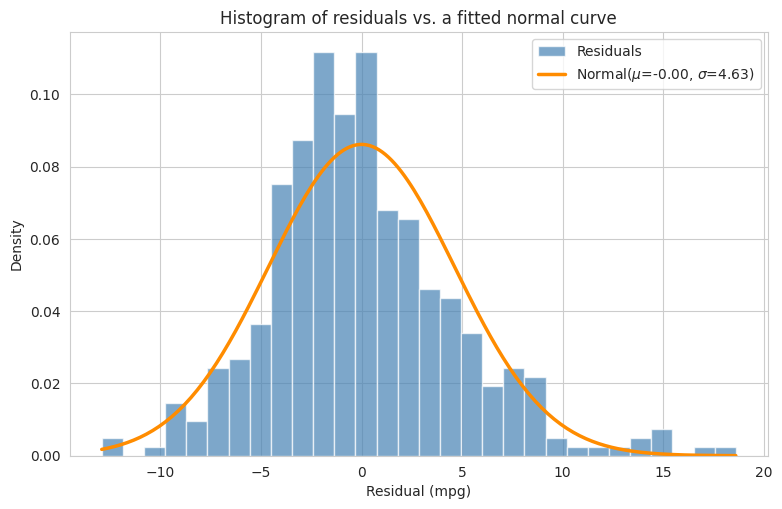

In [6]:
residuals = model.resid

# Overlay a theoretical normal curve with the same mean and std for comparison.
mu, sigma = residuals.mean(), residuals.std()
x_bell = np.linspace(residuals.min(), residuals.max(), 200)
y_bell = stats.norm.pdf(x_bell, mu, sigma)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.hist(residuals, bins=30, density=True, color='steelblue', alpha=0.7, edgecolor='white',
        label='Residuals')
ax.plot(x_bell, y_bell, color='darkorange', linewidth=2.5,
        label=f'Normal($\\mu$={mu:.2f}, $\\sigma$={sigma:.2f})')
ax.set_xlabel('Residual (mpg)')
ax.set_ylabel('Density')
ax.set_title('Histogram of residuals vs. a fitted normal curve')
ax.legend()
plt.show()

The histogram is roughly bell-shaped, but it's a little lopsided — the right tail looks longer than the left. That kind of asymmetry (called **skew**) is hard to judge precisely from a histogram. For that, we use a **Q–Q plot** ("quantile–quantile plot"), which is specifically designed to stress-test normality.

### Reading a Q-Q plot in 30 seconds

A Q–Q plot sorts your residuals from smallest to largest and plots each one against what its value *would be* if the residuals were perfectly normal. The interpretation is delightfully simple:

- **Points fall exactly on the 45° reference line:** residuals are perfectly normal.
- **Points curve off the line at the ends:** the tails are heavier or lighter than normal.
- **Points form an S-shape or banana:** residuals are skewed.

That's it. It's the single most effective tool in statistics for spotting non-normality.

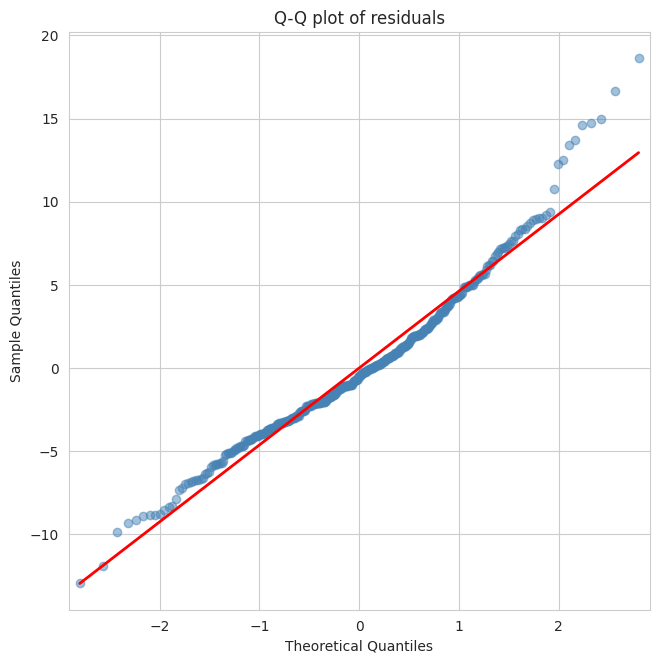

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 7.5))
sm.qqplot(residuals, line='s', ax=ax,
          markerfacecolor='steelblue', markeredgecolor='steelblue', alpha=0.5)
ax.get_lines()[1].set_color('red')   # recolor the reference line
ax.get_lines()[1].set_linewidth(2)
ax.set_title('Q-Q plot of residuals')
plt.show()

The middle of the plot sits right on the red line — that's the main body of the residuals, and it's essentially normal. But look at the **upper right**: the dots curve noticeably *above* the reference line. Those are the unusually large positive residuals — cars whose mpg was dramatically underpredicted. The right tail is heavier than a true normal distribution would have.

Is this a disaster? No. The deviation is mild, it's concentrated in the tails (where only a handful of points sit), and we have 392 observations. The Central Limit Theorem smooths over this kind of minor non-normality. We'd flag it in a write-up but wouldn't throw out the model.

The two extreme failures to watch for in a Q–Q plot are:

- **Both tails curving sharply away from the line** → very heavy tails, possibly outliers you should investigate (coming in Notebook 17_1_4).
- **An S-shape** → badly skewed residuals, usually fixable with a transformation (17_1_5).

---

## Section 4 — E: Equal Variance (Homoscedasticity)

> **The assumption:** the spread of the residuals is the same at every value of $x$ — a constant band of noise.

This one has a beautifully intimidating name (**homoscedasticity**, from Greek *homo* "same" + *skedasis* "dispersion"). Its opposite — unequal variance — is called **heteroscedasticity**. These are two of the vocabulary words you absolutely need to know for technical interviews, and you will see them in almost every regression reference.

Why does it matter? Because the formula for the standard error of the slope *assumes* the noise is the same size everywhere. If the noise gets bigger on one end of $x$, the classical `std err`, p-value, and CI can all be badly miscalibrated.

### What a failure looks like

The signature of unequal variance in a residual plot is a **funnel shape** (or "megaphone"). Let's build a synthetic example so the pattern is unmistakable, then come back to the real MPG data.

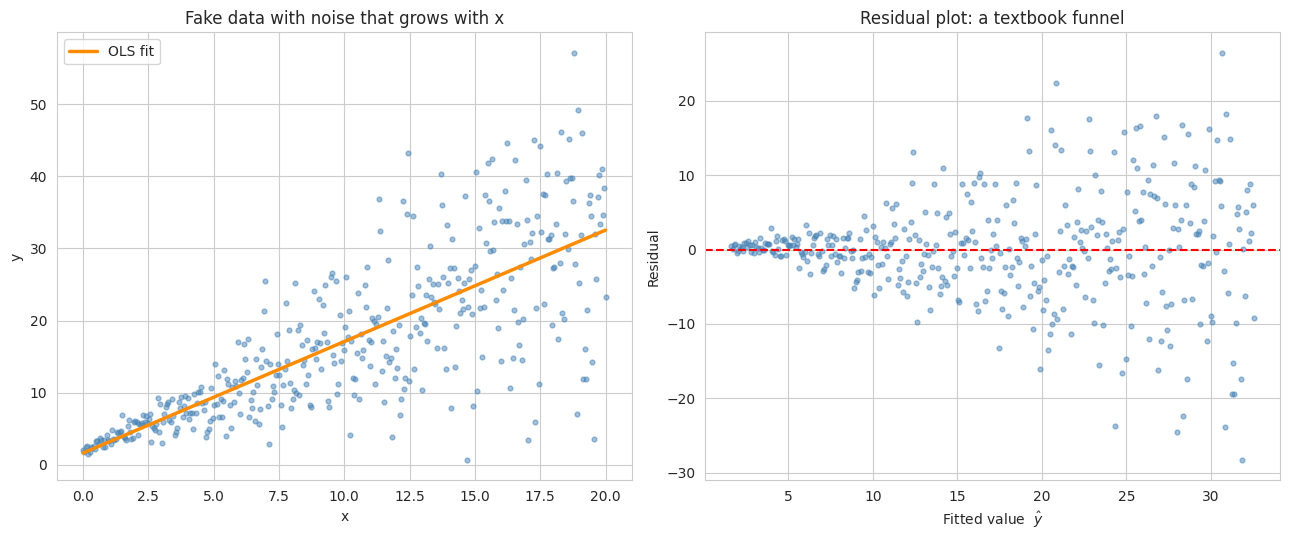

In [8]:
# Synthetic data with noise that grows with x.
x_fake = np.linspace(0, 20, 400)
noise_scale = 0.3 + 0.6 * x_fake        # noise standard deviation grows with x
y_fake = 2 + 1.5 * x_fake + rng.normal(0, noise_scale, size=len(x_fake))

# Fit the usual OLS line.
model_fake = sm.OLS(y_fake, sm.add_constant(x_fake)).fit()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: the data with the fitted line
axes[0].scatter(x_fake, y_fake, s=12, alpha=0.5, color='steelblue')
axes[0].plot(x_fake, model_fake.predict(sm.add_constant(x_fake)),
             color='darkorange', linewidth=2.5, label='OLS fit')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Fake data with noise that grows with x')
axes[0].legend()

# Right: the residual plot
axes[1].scatter(model_fake.fittedvalues, model_fake.resid, s=12, alpha=0.5, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Fitted value  $\\hat{y}$')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual plot: a textbook funnel')

plt.tight_layout()
plt.show()

The left plot shows data that's genuinely linear — no curvature — but the scatter gets wider as $x$ grows. Linearity is fine; equal variance is not.

The right plot makes it obvious: the residuals form a clean funnel, narrow on the left and wide on the right. This is **heteroscedasticity** in its purest form. Once you've seen this shape, you will spot it everywhere — it's the #2 most common residual-plot failure after the U-shape of broken linearity.

### And in our real MPG data?

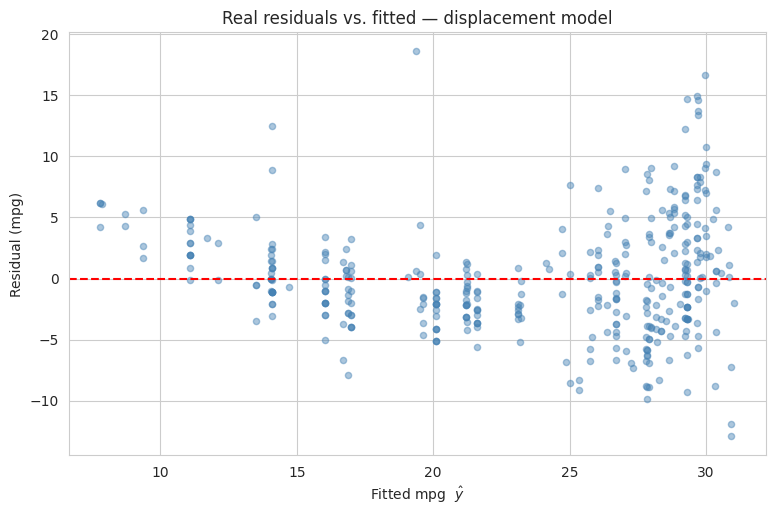

In [9]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(model.fittedvalues, model.resid, s=20, alpha=0.45, color='steelblue')
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Fitted mpg  $\\hat{y}$')
ax.set_ylabel('Residual (mpg)')
ax.set_title('Real residuals vs. fitted — displacement model')
plt.show()

Two things are going on in this plot, and they're both real:

1. **The U-shape from Section 1 is still here.** The lowess curve would swoop negative in the middle and positive at the ends. That's the linearity failure, showing up again in the residuals-vs-fitted view.
2. **The spread is not constant.** The band of residuals is noticeably *wider on the right* (where mpg predictions are high, i.e., for small-engine cars) than on the left (where predictions are low, i.e., big gas-guzzlers). That's a funnel pointing left — equal variance is mildly violated.

So the MPG model is failing two out of four LINE assumptions: linearity and equal variance. Both failures would bias the standard error and p-value that statsmodels reported. *That* is why the summary lied to us — not because the library has a bug, but because we gave it data that violates its assumptions and it didn't know to complain.

---

## What Do You Do When Assumptions Fail?

You have options. Which one you reach for depends on which assumption broke:

| Failure | Common fixes |
|---|---|
| **Linearity** (U or curve in residuals) | Transform $x$ and/or $y$ (log, reciprocal, square root). Add a polynomial term. Use a nonlinear model. |
| **Independence** (serial correlation, clustering) | Use a time-series model (ARIMA, etc.), or a mixed-effects / clustered-error model. |
| **Normality** (S-shape or heavy tails in Q–Q) | Often ignorable with large $N$ (CLT). Otherwise: transform $y$, or use a robust / non-parametric method. |
| **Equal variance** (funnel in residuals) | Transform $y$ (log often works). Or use *robust standard errors* (`model.get_robustcov_results()`) to get correct SEs without retraining. |

The next two notebooks give us real tools for the two most common failures:

- `17_1_4_SLR_Influence.ipynb` — what to do about outliers and high-leverage points (closely tied to the Q–Q heavy-tail warning).
- `17_1_5_SLR_Transformations.ipynb` — how to use log/reciprocal/polynomial transformations to straighten curves and equalize variances. We will come back to this exact MPG dataset and fix it.

---

## Putting It All Together

Every one of these four assumptions has the same basic diagnostic recipe:

> **Fit the model → extract residuals → look at them. If they form a pattern, an assumption is broken.**

Here's the full LINE cheat sheet:

| Letter | Assumption | How to check | What failure looks like |
|:-:|---|---|---|
| **L** | Linearity | `sns.residplot(x, y, lowess=True)` | A curve or bend in the residuals. |
| **I** | Independence | Durbin–Watson (for ordered data); plot residuals vs. time or group | DW far from 2.0; correlated neighbors. |
| **N** | Normality of residuals | Histogram of residuals; `sm.qqplot(resid, line='s')` | Points curve away from the 45° reference line. |
| **E** | Equal variance | Residuals vs. fitted scatter | A funnel / megaphone shape. |

And the larger lesson of this notebook, worth branding into muscle memory:

> **A regression summary table is a mathematical result, not a promise. The slope, the p-value, and the confidence interval are only as trustworthy as the assumptions they're built on. Always check the residuals.**

### Where We're Going Next

So far we've been looking at the *overall* shape of the residuals. But what about a single weird point? A single outlier can drag the whole regression line around, change the p-value, and crater $R^2$. That's what `17_1_4_SLR_Influence.ipynb` is about: **leverage, outliers, and influential observations** — how to find them, how to measure their damage, and when it's legitimate to remove them.